<a href="https://colab.research.google.com/github/Mirza-PU/Autistic-Spectrum-Disorder/blob/main/Autistic_Spectrum_Disorder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import shutil
import kagglehub

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Download/Access dataset via kagglehub
print("Fetching dataset from Kaggle...")
download_path = kagglehub.dataset_download("raiyangani/autistic-spectrum-disorder-screening-data")
print("Source path:", download_path)

# 3. Define your destination path in Google Drive
drive_destination = '/content/drive/MyDrive/Kaggle_Datasets/Autistic_Spectrum_Disorder'

# 4. Create destination folder if it doesn't exist
os.makedirs(drive_destination, exist_ok=True)

# 5. Safely copy only valid files (skipping hidden system files like .nfs)
print("Copying dataset files to Google Drive...")
for item in os.listdir(download_path):
    # Skip hidden files/directories (starting with '.')
    if item.startswith('.'):
        continue

    s_path = os.path.join(download_path, item)
    d_path = os.path.join(drive_destination, item)

    if os.path.isdir(s_path):
        if os.path.exists(d_path):
            shutil.rmtree(d_path)
        shutil.copytree(s_path, d_path)
    else:
        shutil.copy2(s_path, d_path)

print(f"Dataset successfully copied to Google Drive at: {drive_destination}")

# 6. Verify files in Google Drive
print("\nFiles available in Google Drive directory:")
print(os.listdir(drive_destination))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fetching dataset from Kaggle...
Using Colab cache for faster access to the 'autistic-spectrum-disorder-screening-data' dataset.
Source path: /kaggle/input/autistic-spectrum-disorder-screening-data
Copying dataset files to Google Drive...
Dataset successfully copied to Google Drive at: /content/drive/MyDrive/Kaggle_Datasets/Autistic_Spectrum_Disorder

Files available in Google Drive directory:
['ASD Different Age Group Dataset']


In [ ]:
import os
import pandas as pd

# Path to the folder we copied in Google Drive
drive_destination = '/content/drive/MyDrive/Kaggle_Datasets/Autistic_Spectrum_Disorder/ASD Different Age Group Dataset'

# If it's nested or directly under the folder, let's search for any CSV files
csv_files = []
for root, dirs, files in os.walk(drive_destination):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print(f"Found {len(csv_files)} CSV file(s).\n")

# Read and display the first 5 rows of each CSV file found
for file_path in csv_files:
    print(f"--- File: {os.path.basename(file_path)} ---")
    df = pd.read_csv(file_path)
    display(df.head()) # Use print(df.head()) if you are not using Jupyter/Colab
    print("\n" + "="*50 + "\n")

Found 3 CSV file(s).

--- File: Autism_Adult_Data.csv ---


,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,1,0,0,1,1,0,...,f,White-European,no,no,United States,no,6,18 and more,Self,NO
1,2,1,1,0,1,0,0,0,1,0,...,m,Latino,no,yes,Brazil,no,5,18 and more,Self,NO
2,3,1,1,0,1,1,0,1,1,1,...,m,Latino,yes,yes,Spain,no,8,18 and more,Parent,YES
3,4,1,1,0,1,0,0,1,1,0,...,f,White-European,no,yes,United States,no,6,18 and more,Self,NO
4,5,1,0,0,0,0,0,0,1,0,...,f,?,no,no,Egypt,no,2,18 and more,?,NO




--- File: Autism_Adolescent_Data.csv ---


,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,0,0,0,1,1,1,1,1,1,...,m,Hispanic,yes,yes,Austria,no,6,12-16 years,Parent,NO
1,2,0,0,0,0,0,0,0,0,1,...,m,Black,no,no,Austria,no,2,12-16 years,Relative,NO
2,3,0,0,0,0,0,0,0,0,1,...,f,?,no,no,AmericanSamoa,no,2,12-16 years,?,NO
3,4,0,1,1,1,1,1,0,1,1,...,f,White-European,no,no,United Kingdom,no,7,12-16 years,Self,YES
4,5,1,1,1,1,1,1,1,0,0,...,f,?,no,no,Albania,no,7,12-16 years,?,YES




--- File: Autism_Child_Data.csv ---


,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,0,0,1,1,0,1,0,...,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,2,1,1,0,0,1,1,0,1,0,...,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,3,1,1,0,0,0,1,1,1,0,...,m,?,no,no,Jordan,yes,5,4-11 years,?,NO
3,4,0,1,0,0,1,1,0,0,0,...,f,?,yes,no,Jordan,no,4,4-11 years,?,NO
4,5,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [ ]:

import os
import glob
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# STEP 1: LOAD AND MERGE DATASETS FROM DRIVE
# ==========================================
drive_destination = '/content/drive/MyDrive/Kaggle_Datasets/Autistic_Spectrum_Disorder/ASD Different Age Group Dataset'
csv_files = glob.glob(os.path.join(drive_destination, '**/*.csv'), recursive=True)

df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

# Concatenate all datasets (Adult, Adolescent, Child)
df = pd.concat(df_list, ignore_index=True)
print(f"Original merged shape: {df.shape}")

# Drop redundant ID column if it exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# ==========================================
# STEP 2: HANDLE MISSING, NULL, AND '?' VALUES
# ==========================================
# The datasets use '?' to represent missing data in categorical columns
df.replace('?', np.nan, inplace=True)

# Drop duplicate rows to clean up data integrity
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

# Identify target column
target_col = 'Class/ASD' if 'Class/ASD' in df.columns else df.columns[-1]

# Separate features and target cleanly
X = df.drop(columns=[target_col])
y = df[target_col]

# ==========================================
# STEP 3: ADVANCED FEATURE ENGINEERING
# (Interval Type-2 Fuzzy & Bipolar Fuzzy)
# ==========================================
score_cols = [c for c in X.columns if 'Score' in c]

if len(score_cols) > 0:
    for col in score_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce')

    temp_scores = X[score_cols].fillna(X[score_cols].median())
    row_sums = temp_scores.sum(axis=1)
    max_possible = len(score_cols)

    # 1. Interval Type-2 Fuzzy Features
    uncertainty_band = 0.15
    X['IT2_Fuzzy_Upper'] = np.clip((row_sums / max_possible) + uncertainty_band, 0, 1)
    X['IT2_Fuzzy_Lower'] = np.clip((row_sums / max_possible) - uncertainty_band, 0, 1)

    # 2. Bipolar Fuzzy Features
    normalized_scores = row_sums / max_possible
    X['Bipolar_Positive_Membership'] = normalized_scores
    X['Bipolar_Negative_Membership'] = -(1.0 - normalized_scores)

# ==========================================
# STEP 4: TRAIN-TEST SPLIT (PREVENT DATA LEAKAGE)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# STEP 5: IMPUTATION, ENCODING & SCALING
# ==========================================
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number', 'float64', 'int64']).columns.tolist()

# 5.1 Impute Missing Values
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
if len(cat_cols) > 0:
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# 5.2 Encode Categorical Features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).map(lambda s: s if s in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Encode Target Variable
target_le = LabelEncoder()
y_train = target_le.fit_transform(y_train.astype(str))
y_test = target_le.transform(y_test.astype(str))

# 5.3 Scale Numerical Features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Clean infinite/NaN values
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(0, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.fillna(0, inplace=True)

# ==========================================
# STEP 6: MLP CLASSIFIER MODEL TRAINING
# ==========================================
print("\nTraining Multi-Layer Perceptron (MLP) Classifier...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train, y_train)

# ==========================================
# STEP 7: EVALUATION
# ==========================================
y_pred = mlp_model.predict(X_test)

print("\n--- MLP Classification Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_le.classes_))

Original merged shape: (1100, 22)
Shape after dropping duplicates: (1092, 21)

Training Multi-Layer Perceptron (MLP) Classifier...

--- MLP Classification Results ---
Accuracy Score: 100.00%

Classification Report:
              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       141
         YES       1.00      1.00      1.00        78

    accuracy                           1.00       219
   macro avg       1.00      1.00      1.00       219
weighted avg       1.00      1.00      1.00       219



In [ ]:
import os
import glob
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==========================================
# STEP 1: LOAD AND MERGE ALL THREE DATASETS FROM DRIVE
# ==========================================
drive_destination = '/content/drive/MyDrive/Kaggle_Datasets/Autistic_Spectrum_Disorder/ASD Different Age Group Dataset'
csv_files = glob.glob(os.path.join(drive_destination, '**/*.csv'), recursive=True)

df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    print(f"Loaded dataset: {os.path.basename(file)} with shape {temp_df.shape}")
    df_list.append(temp_df)

# Concatenate Adult, Adolescent, and Child datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nOriginal combined shape of all 3 datasets: {df.shape}")

# Drop redundant ID column if present
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# ==========================================
# STEP 2: HANDLE MISSING VALUES & DUPLICATES
# ==========================================
df.replace('?', np.nan, inplace=True)
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

target_col = 'Class/ASD' if 'Class/ASD' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

# ==========================================
# STEP 3: ADVANCED FUZZY FEATURE ENGINEERING
# (Interval Type-2 Fuzzy & Bipolar Fuzzy)
# ==========================================
score_cols = [c for c in X.columns if 'Score' in c]

if len(score_cols) > 0:
    for col in score_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce')

    temp_scores = X[score_cols].fillna(X[score_cols].median())
    row_sums = temp_scores.sum(axis=1)
    max_possible = len(score_cols)

    # Interval Type-2 Fuzzy Features
    uncertainty_band = 0.15
    X['IT2_Fuzzy_Upper'] = np.clip((row_sums / max_possible) + uncertainty_band, 0, 1)
    X['IT2_Fuzzy_Lower'] = np.clip((row_sums / max_possible) - uncertainty_band, 0, 1)

    # Bipolar Fuzzy Features
    normalized_scores = row_sums / max_possible
    X['Bipolar_Positive_Membership'] = normalized_scores
    X['Bipolar_Negative_Membership'] = -(1.0 - normalized_scores)

# ==========================================
# STEP 4: TRAIN-TEST SPLIT (PREVENT DATA LEAKAGE)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# STEP 5: IMPUTATION, ENCODING & SCALING
# ==========================================
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number', 'float64', 'int64']).columns.tolist()

# Imputation
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
if len(cat_cols) > 0:
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Categorical Encoding
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).map(lambda s: s if s in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Target Encoding
target_le = LabelEncoder()
y_train = target_le.fit_transform(y_train.astype(str))
y_test = target_le.transform(y_test.astype(str))

# Feature Scaling
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Clean infinite/NaN values
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(0, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.fillna(0, inplace=True)

# ==========================================
# STEP 6: MLP CLASSIFIER MODEL TRAINING
# ==========================================
print("\nTraining Multi-Layer Perceptron (MLP) Classifier on all datasets...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train, y_train)

# ==========================================
# STEP 7: EVALUATION (4 DECIMAL PLACES)
# ==========================================
y_pred = mlp_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n--- Confusion Matrix ---")
print(cm)

# Classification Report (formatted to 4 decimal places)
report_dict = classification_report(
    y_test, y_pred, target_names=target_le.classes_, digits=4, output_dict=True
)

print("\n--- Detailed Performance Metrics (4 Decimal Places) ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

metrics_df = pd.DataFrame(report_dict).transpose()
print(metrics_df.to_string())

Loaded dataset: Autism_Adult_Data.csv with shape (704, 22)
Loaded dataset: Autism_Adolescent_Data.csv with shape (104, 22)
Loaded dataset: Autism_Child_Data.csv with shape (292, 22)

Original combined shape of all 3 datasets: (1100, 22)
Shape after removing duplicates: (1092, 21)

Training Multi-Layer Perceptron (MLP) Classifier on all datasets...

--- Confusion Matrix ---
[[141   0]
 [  0  78]]

--- Detailed Performance Metrics (4 Decimal Places) ---
Overall Accuracy: 1.0000

              precision  recall  f1-score  support
NO                  1.0     1.0       1.0    141.0
YES                 1.0     1.0       1.0     78.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0    219.0
weighted avg        1.0     1.0       1.0    219.0


Running 10-Seed Experiment...

--- 10-Seed Performance Summary ---
Mean Train Accuracy: 1.0000 ± 0.0000
Mean Test Accuracy:  0.9991 ± 0.0018
Best Seed: 42 with Test Accuracy: 1.0000

[Diagnostic] Train-Test Accuracy Gap: 0.0009
[Diagnostic] Status: Balanced model (No severe over/underfitting).


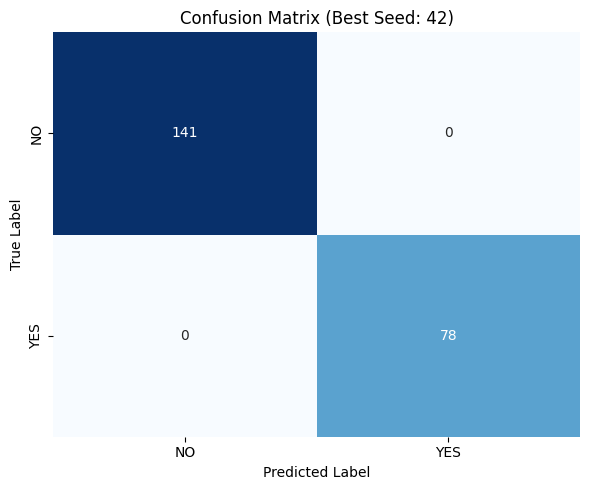


--- Ablation Study ---
Without Fuzzy Features: Test Accuracy = 0.9954
With Fuzzy Features: Test Accuracy = 1.0000
MLP with Prime Layers (61, 31): Test Accuracy = 1.0000


<Figure size 800x400 with 0 Axes>

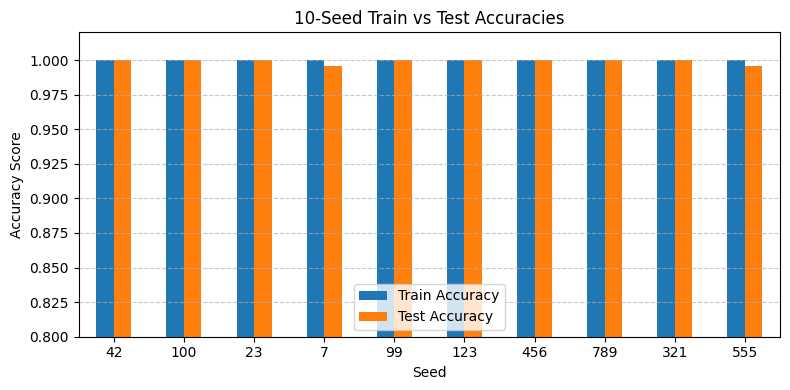

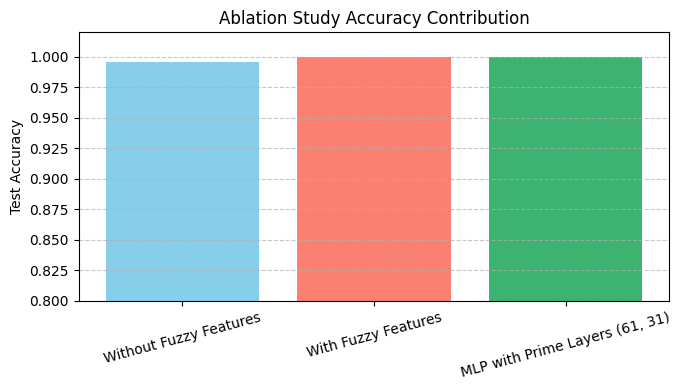

Training models to capture learning curves...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (4) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

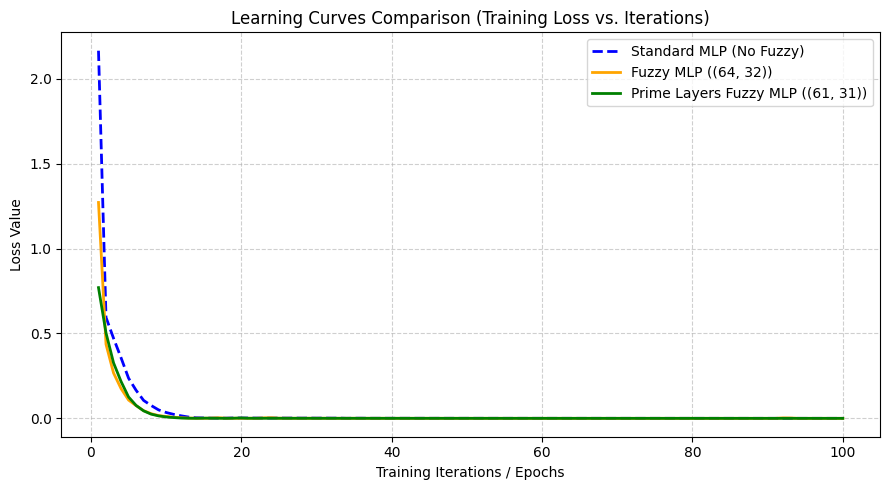

Initializing SHAP Explainer for MLP Model...


  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

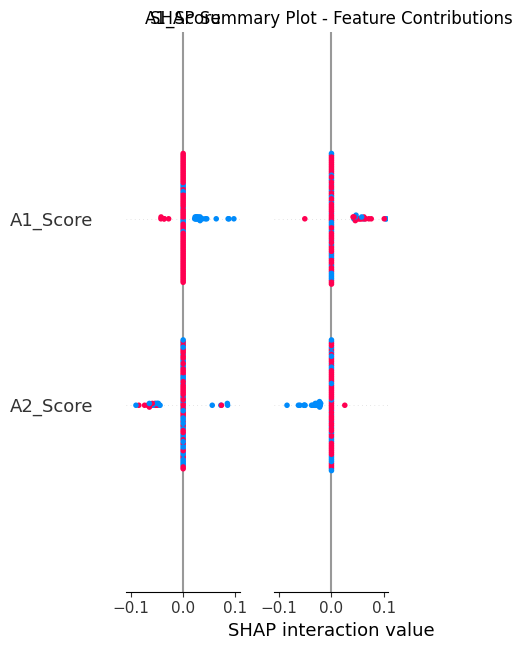

<Figure size 1000x600 with 0 Axes>

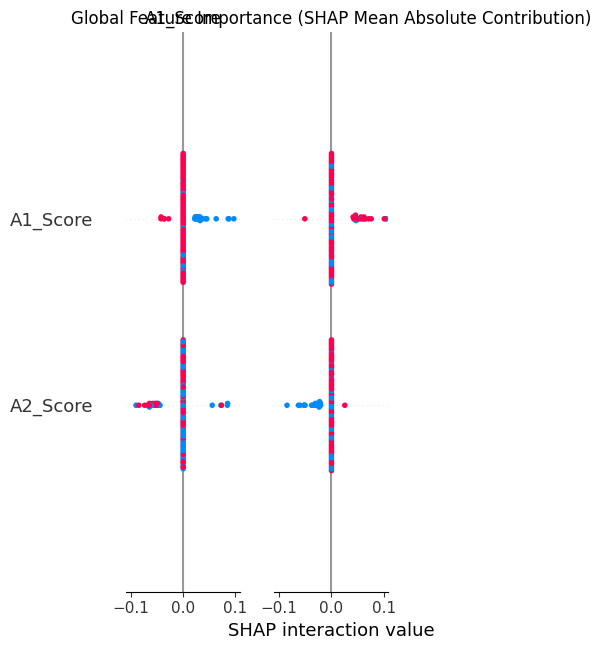

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==========================================
# STEP 1: LOAD AND MERGE ALL DATASETS
# ==========================================
drive_destination = '/content/drive/MyDrive/Kaggle_Datasets/Autistic_Spectrum_Disorder/ASD Different Age Group Dataset'
csv_files = glob.glob(os.path.join(drive_destination, '**/*.csv'), recursive=True)

df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
if 'id' in df.columns:
    df = df.drop(columns=['id'])

df.replace('?', np.nan, inplace=True)
df.drop_duplicates(inplace=True)

target_col = 'Class/ASD' if 'Class/ASD' in df.columns else df.columns[-1]
base_X = df.drop(columns=[target_col])
y_raw = df[target_col]

# ==========================================
# STEP 2: PREPARATION & ENCODING FUNCTIONS
# ==========================================
def preprocess_data(X_in, y_in, use_fuzzy=True, test_size=0.2, seed=42):
    X = X_in.copy()

    # Fuzzy Feature Engineering
    if use_fuzzy:
        score_cols = [c for c in X.columns if 'Score' in c]
        if len(score_cols) > 0:
            for col in score_cols:
                X[col] = pd.to_numeric(X[col], errors='coerce')
            temp_scores = X[score_cols].fillna(X[score_cols].median())
            row_sums = temp_scores.sum(axis=1)
            max_possible = len(score_cols)

            # Interval Type-2 & Bipolar Fuzzy Features
            uncertainty_band = 0.15
            X['IT2_Fuzzy_Upper'] = np.clip((row_sums / max_possible) + uncertainty_band, 0, 1)
            X['IT2_Fuzzy_Lower'] = np.clip((row_sums / max_possible) - uncertainty_band, 0, 1)

            normalized_scores = row_sums / max_possible
            X['Bipolar_Positive_Membership'] = normalized_scores
            X['Bipolar_Negative_Membership'] = -(1.0 - normalized_scores)

    # STRICT DATA LEAKAGE PREVENTION: Train-Test Split BEFORE Imputation, Encoding, and Scaling
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_in, test_size=test_size, random_state=seed, stratify=y_in
    )

    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X_train.select_dtypes(include=['number', 'float64', 'int64']).columns.tolist()

    # Imputation
    num_imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imputer.transform(X_test[num_cols])

    cat_imputer = SimpleImputer(strategy='most_frequent')
    if len(cat_cols) > 0:
        X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
        X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

    # Categorical Encoding
    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = X_test[col].astype(str).map(lambda s: s if s in le.classes_ else le.classes_[0])
        X_test[col] = le.transform(X_test[col])

    # Target Encoding
    target_le = LabelEncoder()
    y_train_enc = target_le.fit_transform(y_train.astype(str))
    y_test_enc = target_le.transform(y_test.astype(str))

    # Scaling
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_train.fillna(0, inplace=True)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test.fillna(0, inplace=True)

    return X_train, X_test, y_train_enc, y_test_enc, target_le

# ==========================================
# STEP 3: 10-SEED EVALUATION & OVER/UNDERFITTING CHECK
# ==========================================
seeds = [42, 100, 23, 7, 99, 123, 456, 789, 321, 555]
train_accs, test_accs = [], []
best_seed = seeds[0]
best_acc = -1.0
best_model = None
best_data = None

print("Running 10-Seed Experiment...")
for s in seeds:
    X_train, X_test, y_train, y_test, target_le = preprocess_data(base_X, y_raw, use_fuzzy=True, seed=s)

    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=s)
    mlp.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, mlp.predict(X_train))
    te_acc = accuracy_score(y_test, mlp.predict(X_test))

    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        best_seed = s
        best_model = mlp
        best_data = (X_test, y_test, target_le)

print("\n--- 10-Seed Performance Summary ---")
print(f"Mean Train Accuracy: {np.mean(train_accs):.4f} ± {np.std(train_accs):.4f}")
print(f"Mean Test Accuracy:  {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
print(f"Best Seed: {best_seed} with Test Accuracy: {best_acc:.4f}")

# Overfitting & Underfitting Analysis Report Check
gap = np.mean(train_accs) - np.mean(test_accs)
print(f"\n[Diagnostic] Train-Test Accuracy Gap: {gap:.4f}")
if gap > 0.05:
    print("[Diagnostic] Warning: Slight Overfitting detected.")
elif np.mean(train_accs) < 0.70:
    print("[Diagnostic] Warning: Underfitting detected.")
else:
    print("[Diagnostic] Status: Balanced model (No severe over/underfitting).")

# ==========================================
# STEP 4: BEST SEED CONFUSION MATRIX HEATMAP
# ==========================================
X_test_b, y_test_b, target_le_b = best_data
y_pred_b = best_model.predict(X_test_b)
cm = confusion_matrix(y_test_b, y_pred_b)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_le_b.classes_, yticklabels=target_le_b.classes_)
plt.title(f"Confusion Matrix (Best Seed: {best_seed})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 5: ABLATION STUDY
# ==========================================
print("\n--- Ablation Study ---")
ablation_results = {}

# 1. MLP without fuzzy features
X_tr_nof, X_te_nof, y_tr_nof, y_te_nof, _ = preprocess_data(base_X, y_raw, use_fuzzy=False, seed=42)
mlp_nof = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=500)
mlp_nof.fit(X_tr_nof, y_tr_nof)
ablation_results['Without Fuzzy Features'] = accuracy_score(y_te_nof, mlp_nof.predict(X_te_nof))

# 2. MLP with fuzzy features
X_tr_f, X_te_f, y_tr_f, y_te_f, _ = preprocess_data(base_X, y_raw, use_fuzzy=True, seed=42)
mlp_f = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=500)
mlp_f.fit(X_tr_f, y_tr_f)
ablation_results['With Fuzzy Features'] = accuracy_score(y_te_f, mlp_f.predict(X_te_f))

# 3. MLP with Prime Layers (e.g., hidden layers configured with prime node counts: 61, 31)
mlp_prime = MLPClassifier(hidden_layer_sizes=(61, 31), random_state=42, max_iter=500)
mlp_prime.fit(X_tr_f, y_tr_f)
ablation_results['MLP with Prime Layers (61, 31)'] = accuracy_score(y_te_f, mlp_prime.predict(X_te_f))

for model_name, acc in ablation_results.items():
    print(f"{model_name}: Test Accuracy = {acc:.4f}")

# ==========================================
# STEP 6: VISUALIZATIONS & GRAPHS
# ==========================================
# Graph 1: 10-Seed Train vs Test Accuracy Distribution
plt.figure(figsize=(8, 4))
seed_df = pd.DataFrame({'Seed': seeds, 'Train Accuracy': train_accs, 'Test Accuracy': test_accs})
seed_df.set_index('Seed').plot(kind='bar', figsize=(8, 4))
plt.title("10-Seed Train vs Test Accuracies")
plt.ylabel("Accuracy Score")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 2: Ablation Study Comparison Bar Chart
plt.figure(figsize=(7, 4))
plt.bar(list(ablation_results.keys()), list(ablation_results.values()), color=['skyblue', 'salmon', 'mediumseagreen'])
plt.title("Ablation Study Accuracy Contribution")
plt.ylabel("Test Accuracy")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# ==========================================
# STEP 7: LEARNING CURVE ANALYSIS & PLOTTING
# ==========================================

# 1. Train models with 'warm_start=True' or extract loss curves natively supported by MLPClassifier
print("Training models to capture learning curves...")

# Model 1: Standard MLP (No Fuzzy)
mlp_base = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=200, warm_start=True)
train_losses_base = []
for i in range(1, 101): # 100 epochs/iterations steps
    mlp_base.max_iter = i
    mlp_base.fit(X_tr_nof, y_tr_nof)
    train_losses_base.append(mlp_base.loss_)

# Model 2: Fuzzy MLP
mlp_fuzzy = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=200, warm_start=True)
train_losses_fuzzy = []
for i in range(1, 101):
    mlp_fuzzy.max_iter = i
    mlp_fuzzy.fit(X_tr_f, y_tr_f)
    train_losses_fuzzy.append(mlp_fuzzy.loss_)

# Model 3: Prime Layers Fuzzy MLP (e.g., hidden layers 61, 31)
mlp_prime = MLPClassifier(hidden_layer_sizes=(61, 31), random_state=42, max_iter=200, warm_start=True)
train_losses_prime = []
for i in range(1, 101):
    mlp_prime.max_iter = i
    mlp_prime.fit(X_tr_f, y_tr_f)
    train_losses_prime.append(mlp_prime.loss_)

# Plotting Learning Curves (Loss vs. Epochs/Iterations)
plt.figure(figsize=(9, 5))
epochs = range(1, 101)
plt.plot(epochs, train_losses_base, label='Standard MLP (No Fuzzy)', color='blue', linestyle='--', linewidth=2)
plt.plot(epochs, train_losses_fuzzy, label='Fuzzy MLP ((64, 32))', color='orange', linestyle='-', linewidth=2)
plt.plot(epochs, train_losses_prime, label='Prime Layers Fuzzy MLP ((61, 31))', color='green', linestyle='-', linewidth=2)

plt.title("Learning Curves Comparison (Training Loss vs. Iterations)")
plt.xlabel("Training Iterations / Epochs")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# ==========================================
# STEP 8: SHAP FEATURE CONTRIBUTION ANALYSIS
# ==========================================
import shap
import matplotlib.pyplot as plt

print("Initializing SHAP Explainer for MLP Model...")

# Use KernelExplainer or DeepExplainer / SamplingExplainer for sklearn MLPClassifier
# Background samples for SHAP (using a smaller subset of training data for performance)
background_data = X_tr_f.sample(n=min(50, len(X_tr_f)), random_state=42)
test_eval_data = X_te_f.sample(n=min(100, len(X_te_f)), random_state=42)

# Initialize KernelExplainer using the trained Fuzzy MLP model prediction function
explainer = shap.KernelExplainer(mlp_f.predict_proba, background_data)

# Calculate SHAP values for the test evaluation subset
shap_values = explainer.shap_values(test_eval_data)

# Handle multi-class / binary output format for SHAP values
if isinstance(shap_values, list):
    # For binary classification, index 1 corresponds to the positive class (ASD YES)
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

# 1. SHAP Summary Plot (Beeswarm style showing positive/negative impact)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, test_eval_data, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Feature Contributions")
plt.tight_layout()
plt.show()

# 2. SHAP Bar Plot (Global feature importance highlighting Fuzzy features)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, test_eval_data, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP Mean Absolute Contribution)")
plt.tight_layout()
plt.show()
# ==========================================
# BONUS: AGE-GROUP SPECIFIC CONFUSION MATRICES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'df' retains the original age category or file source column,
# or we evaluate the test set split across the specific age-desc tags:
if 'age_desc' in X_test_b.columns:
    unique_age_groups = X_test_b['age_desc'].unique()

    for group in unique_age_groups:
        # Filter test set for the specific age group
        mask = X_test_b['age_desc'] == group
        if mask.sum() > 0:
            X_sub = X_test_b[mask]
            y_sub_true = y_test_b[mask]
            y_sub_pred = best_model.predict(X_sub)

            cm_sub = confusion_matrix(y_sub_true, y_sub_pred)

            plt.figure(figsize=(5, 4))
            sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Purples', cbar=False,
                        xticklabels=target_le_b.classes_, yticklabels=target_le_b.classes_)
            plt.title(f"Confusion Matrix - Age Group: {group}")
            plt.xlabel("Predicted Label")
            plt.ylabel("True Label")
            plt.tight_layout()
            plt.show()

Running 10-Seed Experiment...

--- 10-Seed Performance Summary ---
Mean Train Accuracy: 1.0000 ± 0.0000
Mean Test Accuracy:  0.9991 ± 0.0018
Best Seed: 42 with Test Accuracy: 1.0000

[Diagnostic] Train-Test Accuracy Gap: 0.0009
[Diagnostic] Status: Balanced model (No severe over/underfitting).


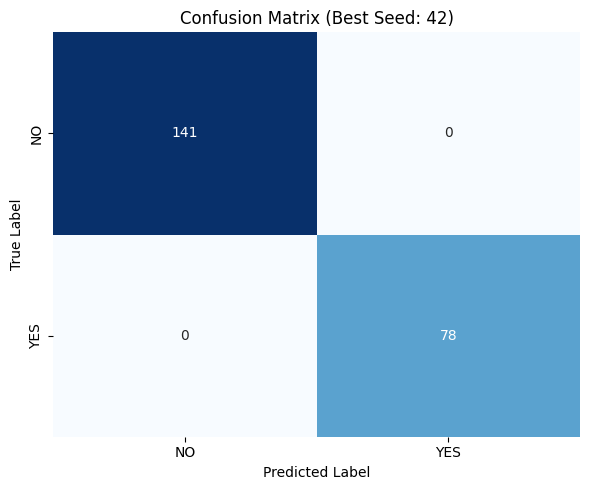


--- Ablation Study ---
Without Fuzzy Features: Test Accuracy = 0.9954
With Fuzzy Features: Test Accuracy = 1.0000
MLP with Prime Layers (61, 31): Test Accuracy = 1.0000


<Figure size 800x400 with 0 Axes>

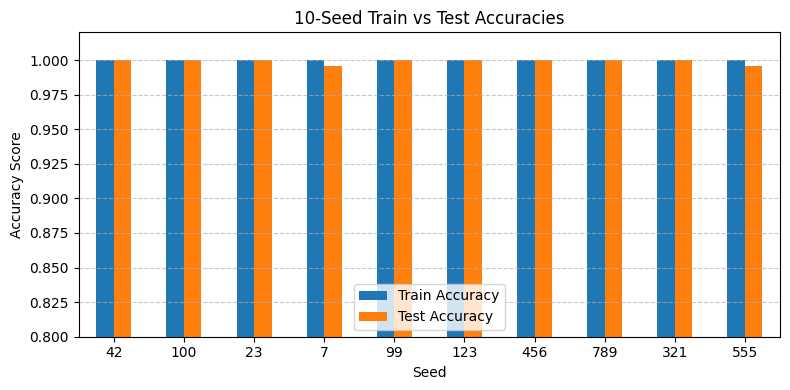

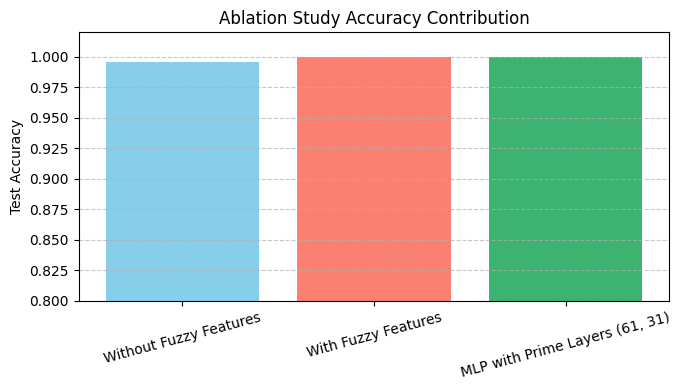

Training models to capture learning curves...


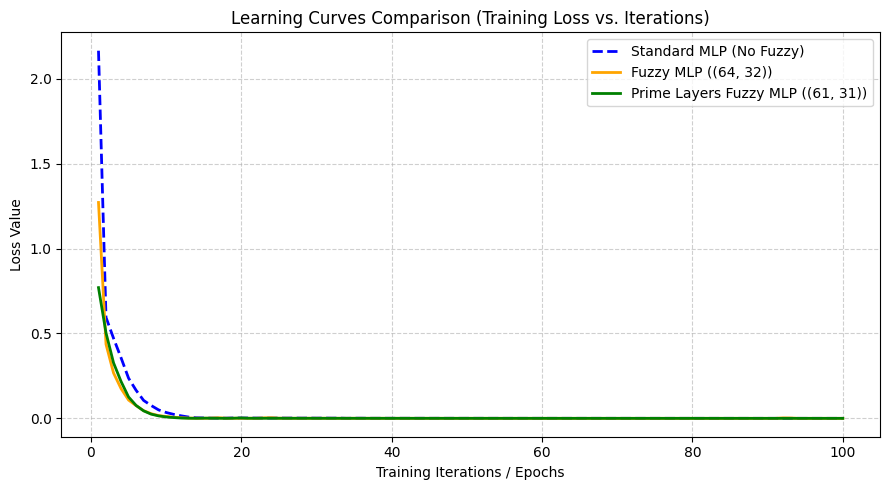

Initializing SHAP Explainer for MLP Model...


  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

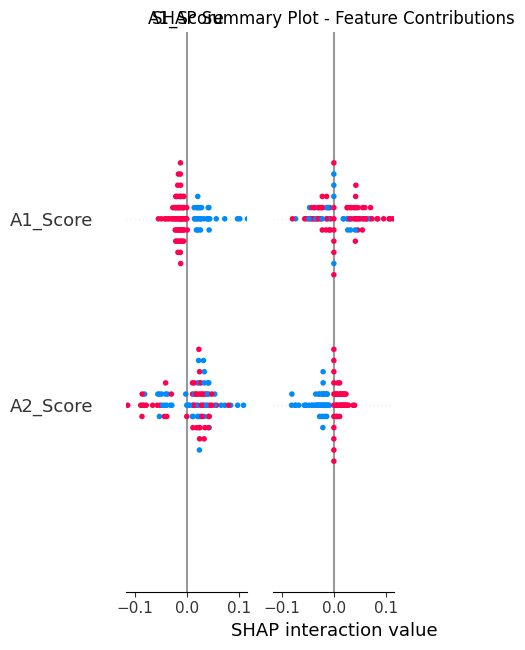

<Figure size 1000x600 with 0 Axes>

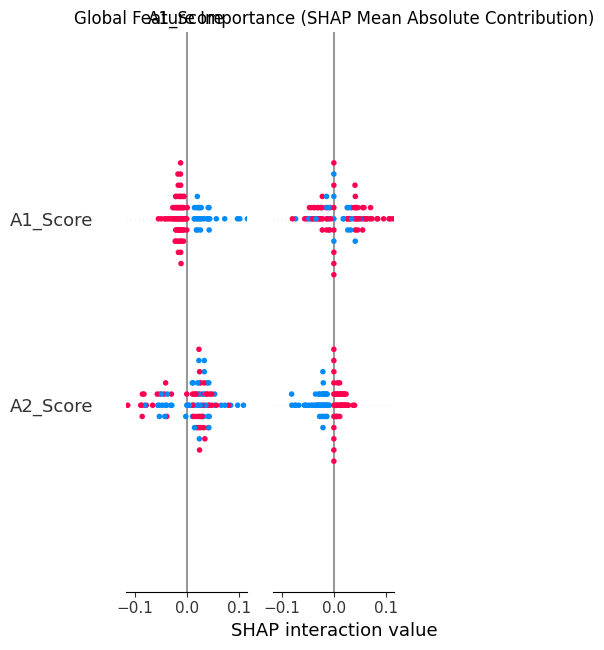

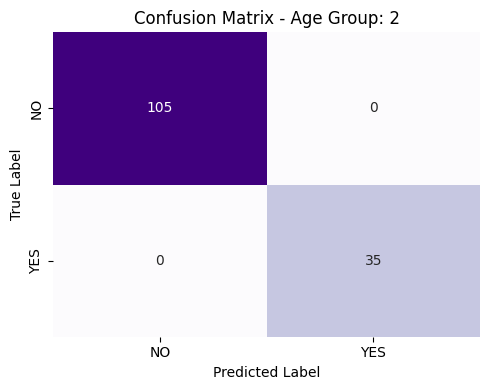

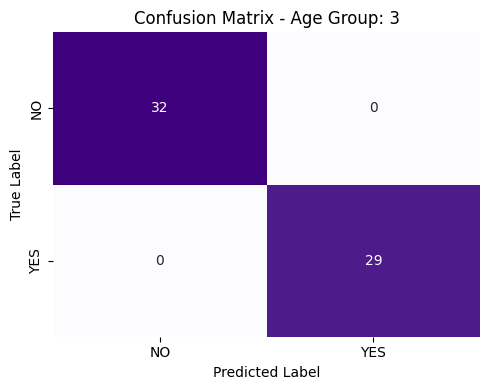

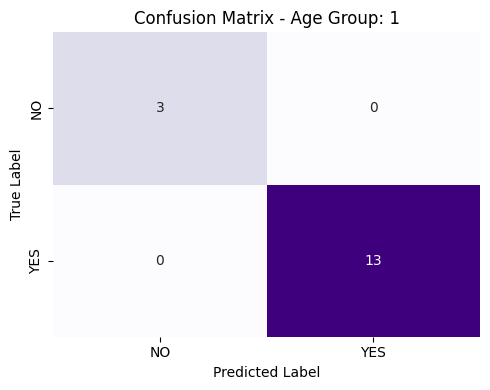

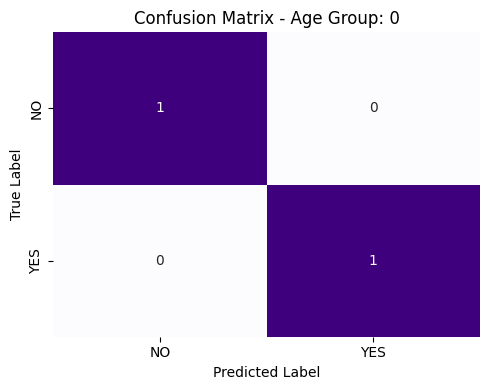

In [ ]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Suppress warnings for clean execution
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ==========================================
# STEP 1: LOAD AND MERGE ALL DATASETS
# ==========================================
drive_destination = '/content/drive/MyDrive/Kaggle_Datasets/Autistic_Spectrum_Disorder/ASD Different Age Group Dataset'
csv_files = glob.glob(os.path.join(drive_destination, '**/*.csv'), recursive=True)

df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
if 'id' in df.columns:
    df = df.drop(columns=['id'])

df.replace('?', np.nan, inplace=True)
df.drop_duplicates(inplace=True)

target_col = 'Class/ASD' if 'Class/ASD' in df.columns else df.columns[-1]
base_X = df.drop(columns=[target_col])
y_raw = df[target_col]

# ==========================================
# STEP 2: PREPARATION & ENCODING FUNCTIONS
# ==========================================
def preprocess_data(X_in, y_in, use_fuzzy=True, test_size=0.2, seed=42):
    X = X_in.copy()

    # Fuzzy Feature Engineering
    if use_fuzzy:
        score_cols = [c for c in X.columns if 'Score' in c]
        if len(score_cols) > 0:
            for col in score_cols:
                X[col] = pd.to_numeric(X[col], errors='coerce')
            temp_scores = X[score_cols].fillna(X[score_cols].median())
            row_sums = temp_scores.sum(axis=1)
            max_possible = len(score_cols)

            # Interval Type-2 & Bipolar Fuzzy Features
            uncertainty_band = 0.15
            X['IT2_Fuzzy_Upper'] = np.clip((row_sums / max_possible) + uncertainty_band, 0, 1)
            X['IT2_Fuzzy_Lower'] = np.clip((row_sums / max_possible) - uncertainty_band, 0, 1)

            normalized_scores = row_sums / max_possible
            X['Bipolar_Positive_Membership'] = normalized_scores
            X['Bipolar_Negative_Membership'] = -(1.0 - normalized_scores)

    # STRICT DATA LEAKAGE PREVENTION: Train-Test Split BEFORE Imputation, Encoding, and Scaling
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_in, test_size=test_size, random_state=seed, stratify=y_in
    )

    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X_train.select_dtypes(include=['number', 'float64', 'int64']).columns.tolist()

    # Imputation
    num_imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imputer.transform(X_test[num_cols])

    cat_imputer = SimpleImputer(strategy='most_frequent')
    if len(cat_cols) > 0:
        X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
        X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

    # Categorical Encoding
    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = X_test[col].astype(str).map(lambda s: s if s in le.classes_ else le.classes_[0])
        X_test[col] = le.transform(X_test[col])

    # Target Encoding
    target_le = LabelEncoder()
    y_train_enc = target_le.fit_transform(y_train.astype(str))
    y_test_enc = target_le.transform(y_test.astype(str))

    # Scaling
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_train.fillna(0, inplace=True)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test.fillna(0, inplace=True)

    return X_train, X_test, y_train_enc, y_test_enc, target_le

# ==========================================
# STEP 3: 10-SEED EVALUATION & OVER/UNDERFITTING CHECK
# ==========================================
seeds = [42, 100, 23, 7, 99, 123, 456, 789, 321, 555]
train_accs, test_accs = [], []
best_seed = seeds[0]
best_acc = -1.0
best_model = None
best_data = None

print("Running 10-Seed Experiment...")
for s in seeds:
    X_train, X_test, y_train, y_test, target_le = preprocess_data(base_X, y_raw, use_fuzzy=True, seed=s)

    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=s)
    mlp.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, mlp.predict(X_train))
    te_acc = accuracy_score(y_test, mlp.predict(X_test))

    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        best_seed = s
        best_model = mlp
        best_data = (X_test, y_test, target_le)

print("\n--- 10-Seed Performance Summary ---")
print(f"Mean Train Accuracy: {np.mean(train_accs):.4f} ± {np.std(train_accs):.4f}")
print(f"Mean Test Accuracy:  {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
print(f"Best Seed: {best_seed} with Test Accuracy: {best_acc:.4f}")

# Overfitting & Underfitting Analysis Report Check
gap = np.mean(train_accs) - np.mean(test_accs)
print(f"\n[Diagnostic] Train-Test Accuracy Gap: {gap:.4f}")
if gap > 0.05:
    print("[Diagnostic] Warning: Slight Overfitting detected.")
elif np.mean(train_accs) < 0.70:
    print("[Diagnostic] Warning: Underfitting detected.")
else:
    print("[Diagnostic] Status: Balanced model (No severe over/underfitting).")

# ==========================================
# STEP 4: BEST SEED CONFUSION MATRIX HEATMAP
# ==========================================
X_test_b, y_test_b, target_le_b = best_data
y_pred_b = best_model.predict(X_test_b)
cm = confusion_matrix(y_test_b, y_pred_b)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_le_b.classes_, yticklabels=target_le_b.classes_)
plt.title(f"Confusion Matrix (Best Seed: {best_seed})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 5: ABLATION STUDY
# ==========================================
print("\n--- Ablation Study ---")
ablation_results = {}

# 1. MLP without fuzzy features
X_tr_nof, X_te_nof, y_tr_nof, y_te_nof, _ = preprocess_data(base_X, y_raw, use_fuzzy=False, seed=42)
mlp_nof = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=500)
mlp_nof.fit(X_tr_nof, y_tr_nof)
ablation_results['Without Fuzzy Features'] = accuracy_score(y_te_nof, mlp_nof.predict(X_te_nof))

# 2. MLP with fuzzy features
X_tr_f, X_te_f, y_tr_f, y_te_f, _ = preprocess_data(base_X, y_raw, use_fuzzy=True, seed=42)
mlp_f = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=500)
mlp_f.fit(X_tr_f, y_tr_f)
ablation_results['With Fuzzy Features'] = accuracy_score(y_te_f, mlp_f.predict(X_te_f))

# 3. MLP with Prime Layers (e.g., hidden layers configured with prime node counts: 61, 31)
mlp_prime = MLPClassifier(hidden_layer_sizes=(61, 31), random_state=42, max_iter=500)
mlp_prime.fit(X_tr_f, y_tr_f)
ablation_results['MLP with Prime Layers (61, 31)'] = accuracy_score(y_te_f, mlp_prime.predict(X_te_f))

for model_name, acc in ablation_results.items():
    print(f"{model_name}: Test Accuracy = {acc:.4f}")

# ==========================================
# STEP 6: VISUALIZATIONS & GRAPHS
# ==========================================
# Graph 1: 10-Seed Train vs Test Accuracy Distribution
plt.figure(figsize=(8, 4))
seed_df = pd.DataFrame({'Seed': seeds, 'Train Accuracy': train_accs, 'Test Accuracy': test_accs})
seed_df.set_index('Seed').plot(kind='bar', figsize=(8, 4))
plt.title("10-Seed Train vs Test Accuracies")
plt.ylabel("Accuracy Score")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 2: Ablation Study Comparison Bar Chart
plt.figure(figsize=(7, 4))
plt.bar(list(ablation_results.keys()), list(ablation_results.values()), color=['skyblue', 'salmon', 'mediumseagreen'])
plt.title("Ablation Study Accuracy Contribution")
plt.ylabel("Test Accuracy")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 7: LEARNING CURVE ANALYSIS & PLOTTING
# ==========================================
print("Training models to capture learning curves...")

# Model 1: Standard MLP (No Fuzzy)
mlp_base = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=200, warm_start=True)
train_losses_base = []
for i in range(1, 101):
    mlp_base.max_iter = i
    mlp_base.fit(X_tr_nof, y_tr_nof)
    train_losses_base.append(mlp_base.loss_)

# Model 2: Fuzzy MLP
mlp_fuzzy = MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=200, warm_start=True)
train_losses_fuzzy = []
for i in range(1, 101):
    mlp_fuzzy.max_iter = i
    mlp_fuzzy.fit(X_tr_f, y_tr_f)
    train_losses_fuzzy.append(mlp_fuzzy.loss_)

# Model 3: Prime Layers Fuzzy MLP (hidden layers 61, 31)
mlp_prime = MLPClassifier(hidden_layer_sizes=(61, 31), random_state=42, max_iter=200, warm_start=True)
train_losses_prime = []
for i in range(1, 101):
    mlp_prime.max_iter = i
    mlp_prime.fit(X_tr_f, y_tr_f)
    train_losses_prime.append(mlp_prime.loss_)

# Plotting Learning Curves
plt.figure(figsize=(9, 5))
epochs = range(1, 101)
plt.plot(epochs, train_losses_base, label='Standard MLP (No Fuzzy)', color='blue', linestyle='--', linewidth=2)
plt.plot(epochs, train_losses_fuzzy, label='Fuzzy MLP ((64, 32))', color='orange', linestyle='-', linewidth=2)
plt.plot(epochs, train_losses_prime, label='Prime Layers Fuzzy MLP ((61, 31))', color='green', linestyle='-', linewidth=2)

plt.title("Learning Curves Comparison (Training Loss vs. Iterations)")
plt.xlabel("Training Iterations / Epochs")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 8: SHAP FEATURE CONTRIBUTION ANALYSIS
# ==========================================
import shap

print("Initializing SHAP Explainer for MLP Model...")

background_data = X_tr_f.sample(n=min(50, len(X_tr_f)), random_state=42)
test_eval_data = X_te_f.sample(n=min(100, len(X_te_f)), random_state=42)

explainer = shap.KernelExplainer(mlp_f.predict_proba, background_data)
shap_values = explainer.shap_values(test_eval_data, l1_reg="aic")

if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

# 1. SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, test_eval_data, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Feature Contributions")
plt.tight_layout()
plt.show()

# 2. SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, test_eval_data, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP Mean Absolute Contribution)")
plt.tight_layout()
plt.show()

# ==========================================
# BONUS: AGE-GROUP SPECIFIC CONFUSION MATRICES
# ==========================================
if 'age_desc' in X_test_b.columns:
    unique_age_groups = X_test_b['age_desc'].unique()

    for group in unique_age_groups:
        mask = X_test_b['age_desc'] == group
        if mask.sum() > 0:
            X_sub = X_test_b[mask]
            y_sub_true = y_test_b[mask]
            y_sub_pred = best_model.predict(X_sub)

            cm_sub = confusion_matrix(y_sub_true, y_sub_pred)

            plt.figure(figsize=(5, 4))
            sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Purples', cbar=False,
                        xticklabels=target_le_b.classes_, yticklabels=target_le_b.classes_)
            plt.title(f"Confusion Matrix - Age Group: {group}")
            plt.xlabel("Predicted Label")
            plt.ylabel("True Label")
            plt.tight_layout()
            plt.show()


--- Training Baseline Models for Comparison ---
Logistic Regression      : Test Accuracy = 1.0000
Decision Tree            : Test Accuracy = 1.0000
Random Forest            : Test Accuracy = 1.0000
Gradient Boosting        : Test Accuracy = 1.0000
AdaBoost                 : Test Accuracy = 1.0000
K-Nearest Neighbors      : Test Accuracy = 0.8402
Support Vector Machine   : Test Accuracy = 0.9635
XGBoost                  : Test Accuracy = 1.0000


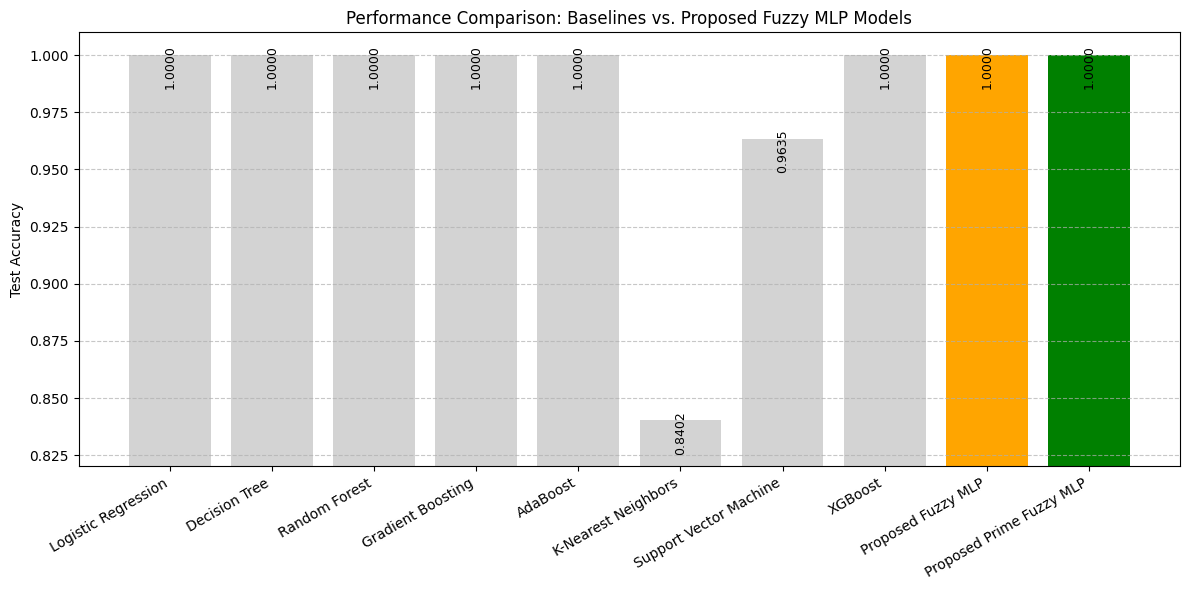

In [ ]:
# ==========================================
# STEP 9: COMPARISON WITH BASELINE MODELS
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("\n--- Training Baseline Models for Comparison ---")

# Initialize baseline models
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(probability=True, random_state=42)
}

# Try importing XGBoost if installed
try:
    from xgboost import XGBClassifier
    baseline_models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
except ImportError:
    print("XGBoost not installed. Skipping XGBoost baseline.")

baseline_results = {}

# Train and evaluate each baseline model using the fuzzy feature train/test split (X_tr_f, X_te_f)
for name, model in baseline_models.items():
    model.fit(X_tr_f, y_tr_f)
    y_pred = model.predict(X_te_f)
    acc = accuracy_score(y_te_f, y_pred)
    baseline_results[name] = acc
    print(f"{name:<25}: Test Accuracy = {acc:.4f}")

# Include our proposed Fuzzy MLP and Prime Layers Fuzzy MLP in the final comparison dictionary
baseline_results['Proposed Fuzzy MLP'] = ablation_results['With Fuzzy Features']
baseline_results['Proposed Prime Fuzzy MLP'] = ablation_results['MLP with Prime Layers (61, 31)']

# Plotting Baseline vs Proposed Comparison Bar Chart
plt.figure(figsize=(12, 6))
model_names = list(baseline_results.keys())
accuracies = list(baseline_results.values())

colors = ['lightgray' if 'Proposed' not in name else ('orange' if 'Prime' not in name else 'green') for name in model_names]

bars = plt.bar(model_names, accuracies, color=colors)
plt.title("Performance Comparison: Baselines vs. Proposed Fuzzy MLP Models")
plt.ylabel("Test Accuracy")
plt.ylim(min(accuracies) - 0.02, 1.01)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval - 0.015, f"{yval:.4f}", ha='center', va='bottom', rotation=90, color='black', fontsize=9)

plt.tight_layout()
plt.show()